<a href="https://colab.research.google.com/github/Neaviyaa230901069/AIML-lab/blob/main/EXP_9_digital_twin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Transfer Function:
 <TransferFunction>: sys[26]
Inputs (1): ['u[0]']
Outputs (1): ['y[0]']

             0.01
  ---------------------------
  0.005 s^2 + 0.06 s + 0.1001

State Space Model:
 <StateSpace>: sys[27]
Inputs (1): ['u[0]']
Outputs (3): ['y[0]', 'y[1]', 'y[2]']
States (3): ['x[0]', 'x[1]', 'x[2]']

A = [[  0.    1.    0. ]
     [  0.   -2.    0.2]
     [  0.   -0.1 -10. ]]

B = [[ 0.]
     [ 0.]
     [10.]]

C = [[1. 0. 0.]
     [0. 1. 0.]
     [0. 0. 1.]]

D = [[0.]
     [0.]
     [0.]]


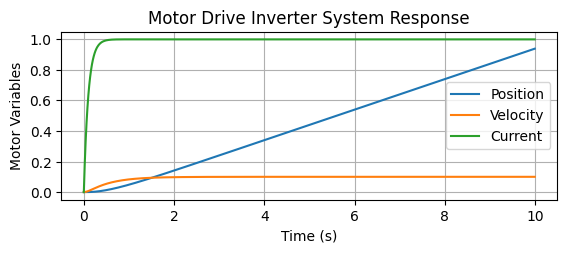

In [ ]:
# Install control library
!pip install control

import numpy as np
import matplotlib.pyplot as plt
import control as ctrl

# Parameters
R = 1
L = 0.1
K = 0.01
J = 0.05
B = 0.1
Ke = 0.01

# Transfer Function
s = ctrl.TransferFunction.s
P_motor = K / ((J*s + B)*(L*s + R) + K**2)
print("Transfer Function:\n", P_motor)

# State-space matrices
A = np.array([[0, 1, 0],
              [0, -B/J, K/J],
              [0, -Ke/L, -R/L]])

B_mat = np.array([[0],
                  [0],
                  [1/L]])

C = np.eye(3)
D = np.zeros((3,1))

# State-space system
sys = ctrl.ss(A, B_mat, C, D)
print("\nState Space Model:\n", sys)

# Time vector
t = np.arange(0, 10, 0.01)

# Input signal
u = np.ones_like(t)

# ✅ FIXED: only 2 outputs
t_out, y_out = ctrl.forced_response(sys, T=t, U=u)

# Plot
plt.figure()

plt.subplot(2,1,1)
plt.plot(t_out, y_out[0], label='Position')
plt.plot(t_out, y_out[1], label='Velocity')
plt.plot(t_out, y_out[2], label='Current')

plt.xlabel('Time (s)')
plt.ylabel('Motor Variables')
plt.title('Motor Drive Inverter System Response')
plt.legend()
plt.grid()

plt.show()
